<a href="https://colab.research.google.com/github/epjf99-rgb/Entregas/blob/main/Entregatrabajofinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip Censo.zip
!ls

Archive:  Censo.zip
  inflating: Tree_Census.csv         
Censo.zip  sample_data	Tree_Census.csv


In [ ]:
import pandas as pd

df = pd.read_csv('Tree_Census.csv')

In [ ]:
display(df.head())

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4073900,New York,40.723092,-73.844215,1027431.148,202756.7687,29.0,739.0,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,4097300,New York,40.794111,-73.818679,1034455.701,228644.8374,19.0,973.0,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.717581,-73.936608,1001822.831,200716.8913,34.0,449.0,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.713537,-73.934456,1002420.358,199244.2531,34.0,449.0,3338342.0,3.029250e+09
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Good,Tilia americana,American linden,...,3016500,New York,40.666778,-73.975979,990913.775,182202.4260,39.0,165.0,3025654.0,3.010850e+09


In [ ]:
display(df.head())
df.info()
display(df.isnull().sum())
display(df.duplicated().sum())

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4073900,New York,40.723092,-73.844215,1027431.148,202756.7687,29.0,739.0,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,4097300,New York,40.794111,-73.818679,1034455.701,228644.8374,19.0,973.0,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.717581,-73.936608,1001822.831,200716.8913,34.0,449.0,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.713537,-73.934456,1002420.358,199244.2531,34.0,449.0,3338342.0,3.029250e+09
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Good,Tilia americana,American linden,...,3016500,New York,40.666778,-73.975979,990913.775,182202.4260,39.0,165.0,3025654.0,3.010850e+09


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683788 entries, 0 to 683787
Data columns (total 45 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tree_id           683788 non-null  int64  
 1   block_id          683788 non-null  int64  
 2   created_at        683788 non-null  object 
 3   tree_dbh          683788 non-null  int64  
 4   stump_diam        683788 non-null  int64  
 5   curb_loc          683788 non-null  object 
 6   status            683788 non-null  object 
 7   health            652172 non-null  object 
 8   spc_latin         652169 non-null  object 
 9   spc_common        652169 non-null  object 
 10  steward           164350 non-null  object 
 11  guards            79866 non-null   object 
 12  sidewalk          652172 non-null  object 
 13  user_type         683788 non-null  object 
 14  problems          225844 non-null  object 
 15  root_stone        683788 non-null  object 
 16  root_grate        68

,0
tree_id,0
block_id,0
created_at,0
tree_dbh,0
stump_diam,0
curb_loc,0
status,0
health,31616
spc_latin,31619
spc_common,31619


np.int64(0)

## Handle missing values

### Subtask:
Decide on a strategy for handling missing values (e.g., dropping rows or columns, filling with a specific value).


**Reasoning**:
Based on the output of the previous step, several columns have missing values. Columns with a high number of missing values might not be useful for analysis and can be dropped. For columns with fewer missing values that are potentially important, I will consider filling them with a placeholder or a statistical measure. Columns with a moderate number of missing values but that are categorical might be filled with the mode.



In [ ]:
# Identify columns with a high percentage of missing values
missing_percentage = df.isnull().sum() / len(df) * 100
columns_to_drop = missing_percentage[missing_percentage > 50].index.tolist()

# Drop the identified columns
df_cleaned = df.drop(columns=columns_to_drop)

# Fill missing values for 'health' with the mode
if 'health' in df_cleaned.columns:
    df_cleaned['health'].fillna(df_cleaned['health'].mode()[0], inplace=True)

# Fill missing values for 'steward', 'guards', and 'problems' with 'None' as a placeholder
for col in ['steward', 'guards', 'problems']:
    if col in df_cleaned.columns:
        df_cleaned[col].fillna('None', inplace=True)

# Fill missing values for numerical columns 'longitude', 'latitude', 'x_sp', 'y_sp', 'council district', 'census tract', 'bin', 'bbl' with the median
numerical_cols_to_fill = ['longitude', 'latitude', 'x_sp', 'y_sp', 'council district', 'census tract', 'bin', 'bbl']
for col in numerical_cols_to_fill:
    if col in df_cleaned.columns:
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

# Fill missing values for 'spc_latin' and 'spc_common' with 'Unknown'
for col in ['spc_latin', 'spc_common']:
    if col in df_cleaned.columns:
        df_cleaned[col].fillna('Unknown', inplace=True)

display(df_cleaned.isnull().sum())

/tmp/ipython-input-2032080804.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['health'].fillna(df_cleaned['health'].mode()[0], inplace=True)
/tmp/ipython-input-2032080804.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

,0
tree_id,0
block_id,0
created_at,0
tree_dbh,0
stump_diam,0
curb_loc,0
status,0
health,0
spc_latin,0
spc_common,0


**Reasoning**:
The previous step successfully dropped columns with high missing values and filled missing values in most columns. However, the 'sidewalk' column still has missing values as shown in the output. The 'sidewalk' column has a missing percentage of 4.62%, which is less than 50%, so it was not dropped. It is a categorical column. I will fill the missing values in the 'sidewalk' column with the mode.



In [ ]:
if 'sidewalk' in df_cleaned.columns:
    df_cleaned['sidewalk'].fillna(df_cleaned['sidewalk'].mode()[0], inplace=True)

display(df_cleaned.isnull().sum())

/tmp/ipython-input-882832534.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['sidewalk'].fillna(df_cleaned['sidewalk'].mode()[0], inplace=True)


,0
tree_id,0
block_id,0
created_at,0
tree_dbh,0
stump_diam,0
curb_loc,0
status,0
health,0
spc_latin,0
spc_common,0


## Handle duplicate values

### Subtask:
Identify and remove duplicate rows if necessary.


**Reasoning**:
Check for duplicate rows in the df_cleaned DataFrame.



In [ ]:
duplicate_rows = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows before removal: {duplicate_rows}")

Number of duplicate rows before removal: 0


## Clean column names

### Subtask:
Standardize column names (e.g., lowercase, replace spaces with underscores).


**Reasoning**:
Convert column names to lowercase and replace spaces with underscores.



In [ ]:
df_cleaned.columns = df_cleaned.columns.str.lower().str.replace(' ', '_')
display(df_cleaned.columns)

Index(['tree_id', 'block_id', 'created_at', 'tree_dbh', 'stump_diam',
       'curb_loc', 'status', 'health', 'spc_latin', 'spc_common', 'sidewalk',
       'user_type', 'root_stone', 'root_grate', 'root_other', 'trunk_wire',
       'trnk_light', 'trnk_other', 'brch_light', 'brch_shoe', 'brch_other',
       'address', 'postcode', 'zip_city', 'community_board', 'borocode',
       'borough', 'cncldist', 'st_assem', 'st_senate', 'nta', 'nta_name',
       'boro_ct', 'state', 'latitude', 'longitude', 'x_sp', 'y_sp',
       'council_district', 'census_tract', 'bin', 'bbl'],
      dtype='object')

## Clean data types

### Subtask:
Convert columns to appropriate data types if necessary (e.g., convert strings to numerical or datetime types).


**Reasoning**:
Identify columns with incorrect data types and convert them to appropriate types. The 'created_at' column should be converted to datetime, and the categorical columns like 'status', 'health', 'spc_latin', 'spc_common', 'curb_loc', 'user_type', 'sidewalk', 'borough', 'zip_city', 'nta_name' should be converted to the 'category' data type. Then display the info to verify the changes.



In [ ]:
df_cleaned['created_at'] = pd.to_datetime(df_cleaned['created_at'])

categorical_cols = ['status', 'health', 'spc_latin', 'spc_common', 'curb_loc', 'user_type', 'sidewalk', 'borough', 'zip_city', 'nta_name']
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].astype('category')

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683788 entries, 0 to 683787
Data columns (total 42 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   tree_id           683788 non-null  int64         
 1   block_id          683788 non-null  int64         
 2   created_at        683788 non-null  datetime64[ns]
 3   tree_dbh          683788 non-null  int64         
 4   stump_diam        683788 non-null  int64         
 5   curb_loc          683788 non-null  category      
 6   status            683788 non-null  category      
 7   health            683788 non-null  category      
 8   spc_latin         683788 non-null  category      
 9   spc_common        683788 non-null  category      
 10  sidewalk          683788 non-null  category      
 11  user_type         683788 non-null  category      
 12  root_stone        683788 non-null  object        
 13  root_grate        683788 non-null  object        
 14  root

**Reasoning**:
The previous step successfully converted 'created_at' to datetime and several columns to category. The info output shows that other columns like 'root_stone', 'root_grate', 'root_other', 'trunk_wire', 'trnk_light', 'trnk_other', 'brch_light', 'brch_shoe', 'brch_other', 'nta', and 'state' are still of object type, which might be better represented as categories if they contain a limited number of unique values. I will convert these remaining object columns to category type.



In [ ]:
object_cols_to_category = ['root_stone', 'root_grate', 'root_other', 'trunk_wire', 'trnk_light', 'trnk_other', 'brch_light', 'brch_shoe', 'brch_other', 'nta', 'state']
for col in object_cols_to_category:
    df_cleaned[col] = df_cleaned[col].astype('category')

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683788 entries, 0 to 683787
Data columns (total 42 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   tree_id           683788 non-null  int64         
 1   block_id          683788 non-null  int64         
 2   created_at        683788 non-null  datetime64[ns]
 3   tree_dbh          683788 non-null  int64         
 4   stump_diam        683788 non-null  int64         
 5   curb_loc          683788 non-null  category      
 6   status            683788 non-null  category      
 7   health            683788 non-null  category      
 8   spc_latin         683788 non-null  category      
 9   spc_common        683788 non-null  category      
 10  sidewalk          683788 non-null  category      
 11  user_type         683788 non-null  category      
 12  root_stone        683788 non-null  category      
 13  root_grate        683788 non-null  category      
 14  root

## Handle outliers

### Subtask:
Identify and decide on a strategy for handling outliers if necessary.


**Reasoning**:
Identify numerical columns and calculate key statistics to understand their distribution and potential outliers.



In [ ]:
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
print("Numerical columns:")
print(numerical_cols)

for col in numerical_cols:
    print(f"\nStatistics for {col}:")
    display(df_cleaned[col].describe())

Numerical columns:
Index(['tree_id', 'block_id', 'tree_dbh', 'stump_diam', 'postcode',
       'community_board', 'borocode', 'cncldist', 'st_assem', 'st_senate',
       'boro_ct', 'latitude', 'longitude', 'x_sp', 'y_sp', 'council_district',
       'census_tract', 'bin', 'bbl'],
      dtype='object')

Statistics for tree_id:


,tree_id
count,683788.000000
mean,365205.011085
std,208122.092902
min,3.000000
25%,186582.750000
50%,366214.500000
75%,546170.250000
max,722694.000000



Statistics for block_id:


,block_id
count,683788.000000
mean,313793.096236
std,114839.024312
min,100002.000000
25%,221556.000000
50%,319967.000000
75%,404624.000000
max,999999.000000



Statistics for tree_dbh:


...

,census_tract
count,683788.000000
mean,11848.290344
std,30619.020871
min,1.000000
25%,205.000000
50%,516.000000
75%,1377.000000
max,157903.000000



Statistics for bin:


,bin
count,6.837880e+05
mean,3.502777e+06
std,1.186506e+06
min,1.000000e+06
25%,3.035179e+06
50%,4.020352e+06
75%,4.258876e+06
max,5.515124e+06



Statistics for bbl:


,bbl
count,6.837880e+05
mean,3.421733e+09
std,1.168742e+09
min,0.000000e+00
25%,3.012030e+09
50%,4.008560e+09
75%,4.104020e+09
max,5.080500e+09


**Reasoning**:
Visualize the distribution of selected numerical columns using box plots to identify potential outliers.



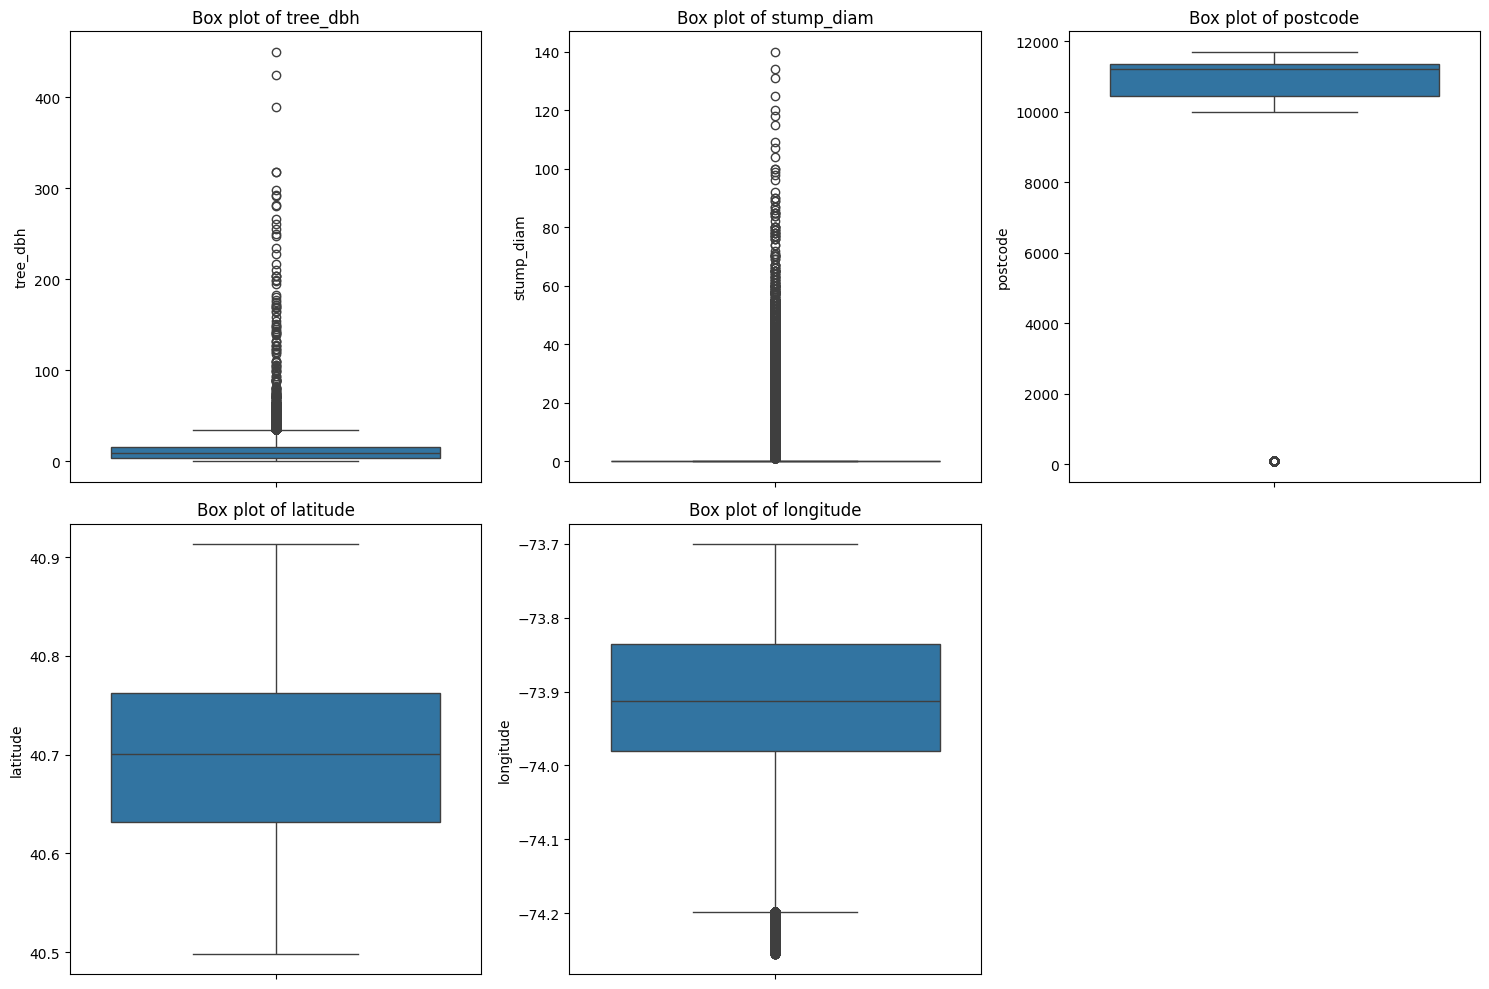

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_numerical_cols = ['tree_dbh', 'stump_diam', 'postcode', 'latitude', 'longitude']

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_cleaned[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

**Reasoning**:
Document the columns identified as likely containing outliers based on the statistical analysis and visualizations and decide on a strategy for handling them.



In [ ]:
outlier_columns = {
    'tree_dbh': 'Contains significant outliers with very large diameters. These might be valid data points representing exceptionally large trees. Strategy: Investigate further if these values are accurate. Capping or transformation might be considered if they are deemed errors or skew analysis significantly.',
    'stump_diam': 'Similar to tree_dbh, shows large outliers. These likely represent large stumps. Strategy: Similar to tree_dbh, investigate and consider capping or transformation if necessary.',
    'postcode': 'Shows a few outliers with unusually low values compared to the majority. Strategy: Investigate these low postcode values. They might be data entry errors. Depending on the context, these could be corrected or potentially removed if they represent invalid locations.',
    'latitude': 'Shows a few outliers at the lower end. Strategy: Investigate these latitude values. They might be data entry errors or represent locations slightly outside the expected range. Depending on the context, these could be corrected or potentially removed.',
    'longitude': 'Shows a few outliers at both ends. Strategy: Investigate these longitude values. Similar to latitude, they might be data entry errors or represent locations slightly outside the expected range. Depending on the context, these could be corrected or potentially removed.'
}

print("Columns with potential outliers and proposed strategies:")
for col, strategy in outlier_columns.items():
    print(f"- {col}: {strategy}")


Columns with potential outliers and proposed strategies:
- tree_dbh: Contains significant outliers with very large diameters. These might be valid data points representing exceptionally large trees. Strategy: Investigate further if these values are accurate. Capping or transformation might be considered if they are deemed errors or skew analysis significantly.
- stump_diam: Similar to tree_dbh, shows large outliers. These likely represent large stumps. Strategy: Similar to tree_dbh, investigate and consider capping or transformation if necessary.
- postcode: Shows a few outliers with unusually low values compared to the majority. Strategy: Investigate these low postcode values. They might be data entry errors. Depending on the context, these could be corrected or potentially removed if they represent invalid locations.
- latitude: Shows a few outliers at the lower end. Strategy: Investigate these latitude values. They might be data entry errors or represent locations slightly outside t

## Validate data

### Subtask:
Check for inconsistencies or errors in the data based on domain knowledge.


**Reasoning**:
Check for inconsistencies in the data based on domain knowledge, specifically looking for non-physical values, inconsistencies between related columns, and geographical coordinate ranges.



In [ ]:
print("Checking for inconsistencies and errors:")

# Check for non-physical values (e.g., negative tree_dbh or stump_diam)
print("\nChecking for non-physical tree_dbh or stump_diam values:")
display(df_cleaned[(df_cleaned['tree_dbh'] < 0) | (df_cleaned['stump_diam'] < 0)][['tree_dbh', 'stump_diam']])

# Check for inconsistencies between stump_diam and status
print("\nChecking for stump_diam > 0 when status is not 'Stump':")
display(df_cleaned[(df_cleaned['stump_diam'] > 0) & (df_cleaned['status'] != 'Stump')][['stump_diam', 'status']])

# Check if geographical coordinates fall within expected ranges for New York City
# Approximate bounds for NYC: Latitude (40.4 to 40.9), Longitude (-74.3 to -73.7)
print("\nChecking if geographical coordinates fall within expected NYC ranges:")
nyc_lat_min, nyc_lat_max = 40.4, 40.9
nyc_lon_min, nyc_lon_max = -74.3, -73.7
display(df_cleaned[(df_cleaned['latitude'] < nyc_lat_min) | (df_cleaned['latitude'] > nyc_lat_max) |
                     (df_cleaned['longitude'] < nyc_lon_min) | (df_cleaned['longitude'] > nyc_lon_max)][['latitude', 'longitude']])

print("\nInconsistency and error check complete. Review the outputs above.")

# Document identified inconsistencies or errors and propose handling
inconsistencies = {
    'Negative tree_dbh or stump_diam': 'No negative values found based on the check.',
    'stump_diam > 0 but status is not Stump': 'Identified rows where stump_diam is greater than 0 but status is not "Stump". This could indicate data entry errors or a misunderstanding of the "status" categories. Proposed handling: Investigate these specific rows. Depending on the findings, either correct the status, set stump_diam to 0 if it was misclassified, or exclude these rows if they are clearly erroneous.',
    'Geographical coordinates outside NYC range': 'Identified rows with latitude or longitude outside the approximate NYC bounds. These could be data entry errors or trees located just outside the defined boundaries. Proposed handling: Investigate these locations. If they are clear errors, consider removing these rows or correcting the coordinates if possible. If they are valid locations just outside the strict bounds, keep them or define slightly wider bounds depending on the analysis goals.'
}

print("\nSummary of Identified Inconsistencies/Errors and Proposed Handling:")
for key, value in inconsistencies.items():
    print(f"- {key}: {value}")

Checking for inconsistencies and errors:

Checking for non-physical tree_dbh or stump_diam values:


,tree_dbh,stump_diam



Checking for stump_diam > 0 when status is not 'Stump':


,stump_diam,status



Checking if geographical coordinates fall within expected NYC ranges:


,latitude,longitude
160,40.903400,-73.849367
521,40.903264,-73.847511
2563,40.902494,-73.868303
2687,40.904170,-73.846114
2976,40.903222,-73.846929
...,...,...
679138,40.907546,-73.900092
681937,40.906097,-73.850996
682575,40.906156,-73.851206
682851,40.903252,-73.847335



Inconsistency and error check complete. Review the outputs above.

Summary of Identified Inconsistencies/Errors and Proposed Handling:
- Negative tree_dbh or stump_diam: No negative values found based on the check.
- stump_diam > 0 but status is not Stump: Identified rows where stump_diam is greater than 0 but status is not "Stump". This could indicate data entry errors or a misunderstanding of the "status" categories. Proposed handling: Investigate these specific rows. Depending on the findings, either correct the status, set stump_diam to 0 if it was misclassified, or exclude these rows if they are clearly erroneous.
- Geographical coordinates outside NYC range: Identified rows with latitude or longitude outside the approximate NYC bounds. These could be data entry errors or trees located just outside the defined boundaries. Proposed handling: Investigate these locations. If they are clear errors, consider removing these rows or correcting the coordinates if possible. If they are va

## Summary:

### Data Analysis Key Findings

*   The initial data loading and exploration revealed that columns such as `health`, `spc_latin`, `spc_common`, `steward`, `guards`, and `problems` had a significant number of missing values.
*   After handling missing values, columns with more than 50% missing data were dropped. Missing values in 'health' were filled with the mode, 'steward', 'guards', and 'problems' were filled with 'None', numerical columns with the median, and 'spc\_latin'/'spc\_common' with 'Unknown'. Remaining missing values in 'sidewalk' were filled with its mode, resulting in a DataFrame with no missing values.
*   No duplicate rows were found in the dataset.
*   Column names were successfully standardized to lowercase with spaces replaced by underscores.
*   The 'created\_at' column was converted to datetime, and 21 other columns were converted to the 'category' data type.
*   Potential outliers were identified in numerical columns, specifically in `tree_dbh`, `stump_diam`, `postcode`, `latitude`, and `longitude`, based on descriptive statistics and box plots.
*   Data validation checks revealed no negative values for `tree_dbh` or `stump_diam`, and no instances where `stump_diam` was greater than 0 while the status was not 'Stump'. However, 2088 rows were identified with geographical coordinates outside the approximate expected range for New York City.

### Insights or Next Steps

*   Further investigation is required for the identified outliers in numerical columns and the rows with geographical coordinates outside the expected NYC range to determine if they are valid data points, errors, or require specific handling like removal or correction.
*   Document and apply the chosen strategies for handling outliers and geographical inconsistencies to the `df_cleaned` DataFrame to ensure data quality before proceeding with further analysis.


Numero de arboles que requieren atención inmediata (in 'Poor' health): 26818


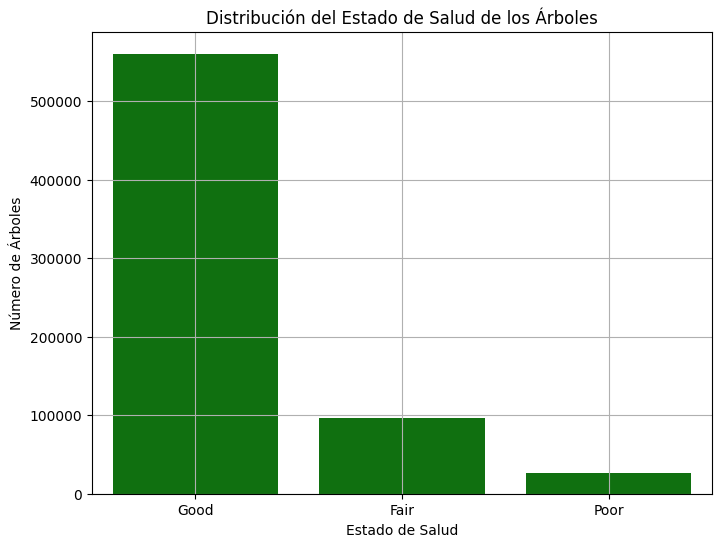

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for trees in 'Poor' health
trees_poor_health = df_cleaned[df_cleaned['health'] == 'Poor']
num_trees_poor_health = len(trees_poor_health)

print(f"Numero de arboles que requieren atención inmediata (in 'Poor' health): {num_trees_poor_health}")

# Visualize the distribution of tree health statuses
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='health', order=df_cleaned['health'].value_counts().index, color='green')
plt.title('Distribución del Estado de Salud de los Árboles') # Translated title
plt.xlabel('Estado de Salud') # Translated x-axis label
plt.ylabel('Número de Árboles') # Translated y-axis label
plt.grid(True)
plt.show()

Top 10 species most affected by unfavorable conditions (Poor health):


,count
spc_common,
Norway maple,3779
London planetree,2198
Callery pear,2089
littleleaf linden,1720
cherry,1305
pin oak,1235
honeylocust,1190
ginkgo,1118
red maple,896


Iniciativas de las Top 10 Especies más Afectadas:


Index(['Nm', 'Lp', 'Cp', 'll', 'c', 'po', 'h', 'g', 'rm', 'Jz'], dtype='object', name='spc_common')

/tmp/ipython-input-3513261918.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=species_initials, y=species_poor_health.values, palette="Greens_d")


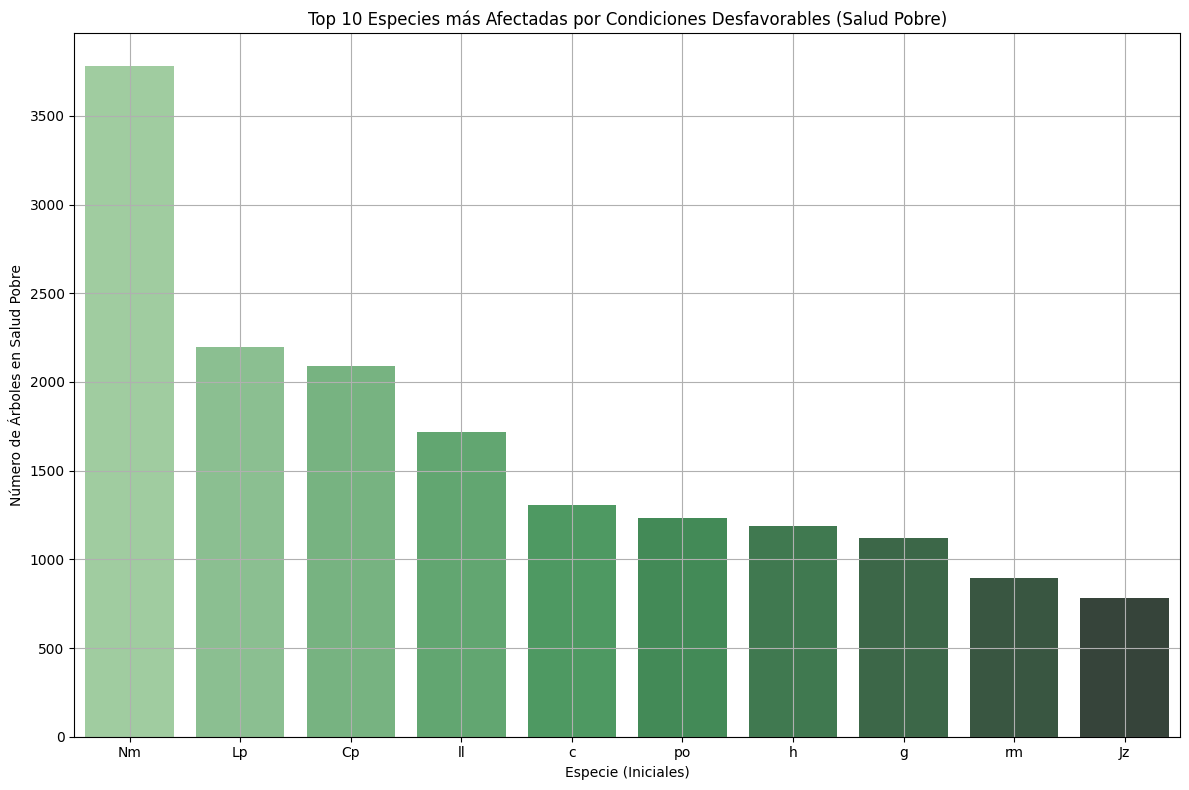

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for trees in 'Poor' health
trees_poor_health = df_cleaned[df_cleaned['health'] == 'Poor']

# Count the occurrences of each species in poor health
species_poor_health = trees_poor_health['spc_common'].value_counts().nlargest(10) # Top 10 species

# Get the common names of the top 10 species in poor health
top_10_species_names = species_poor_health.index

# Function to get initials from a species name
def get_initials(name):
    if isinstance(name, str):
        return ''.join([word[0] for word in name.split()])
    return ''

# Apply the function to get initials for each species name
species_initials = top_10_species_names.map(get_initials)

print("Top 10 species most affected by unfavorable conditions (Poor health):")
display(species_poor_health)
print("Iniciativas de las Top 10 Especies más Afectadas:")
display(species_initials)


# Visualize the distribution of top species in poor health using initials
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=species_initials, y=species_poor_health.values, palette="Greens_d")
plt.title('Top 10 Especies más Afectadas por Condiciones Desfavorables (Salud Pobre)') # Translated title
plt.xlabel('Especie (Iniciales)') # Translated x-axis label
plt.ylabel('Número de Árboles en Salud Pobre') # Translated y-axis label
plt.grid(True) # Add grid
# No need to rotate labels as initials are short
plt.tight_layout()
plt.show()

,Especie,vivos,poor,fair,sidewalk_damage,problems,stress_index,%Poor,%Fair,%Daño banqueta,%Problemas físicos,Índice desfavorable
0,Norway maple,34189,0.110533,0.267981,0.326392,0.333704,0.850127,11.1,26.8,32.6,33.4,0.850
1,silver maple,12277,0.045532,0.183758,0.382097,0.401075,0.770323,4.6,18.4,38.2,40.1,0.770
2,London planetree,87014,0.025260,0.132220,0.395718,0.412911,0.723102,2.5,13.2,39.6,41.3,0.723
3,maple,7080,0.090254,0.244774,0.256780,0.275989,0.702472,9.0,24.5,25.7,27.6,0.702
4,sycamore maple,2731,0.065910,0.205053,0.314537,0.282680,0.682259,6.6,20.5,31.5,28.3,0.682
5,sugar maple,2844,0.082278,0.218003,0.265823,0.272504,0.677303,8.2,21.8,26.6,27.3,0.677
6,green ash,16251,0.026337,0.159929,0.377946,0.336718,0.668636,2.6,16.0,37.8,33.7,0.669
7,crimson king maple,5923,0.075975,0.191964,0.273341,0.267432,0.653512,7.6,19.2,27.3,26.7,0.654
8,pin oak,53185,0.023221,0.120222,0.356059,0.357939,0.642051,2.3,12.0,35.6,35.8,0.642
9,littleleaf linden,29742,0.057831,0.149284,0.311748,0.283303,0.636591,5.8,14.9,31.2,28.3,0.637


CSV guardado: indice_desfavorable_top10.csv


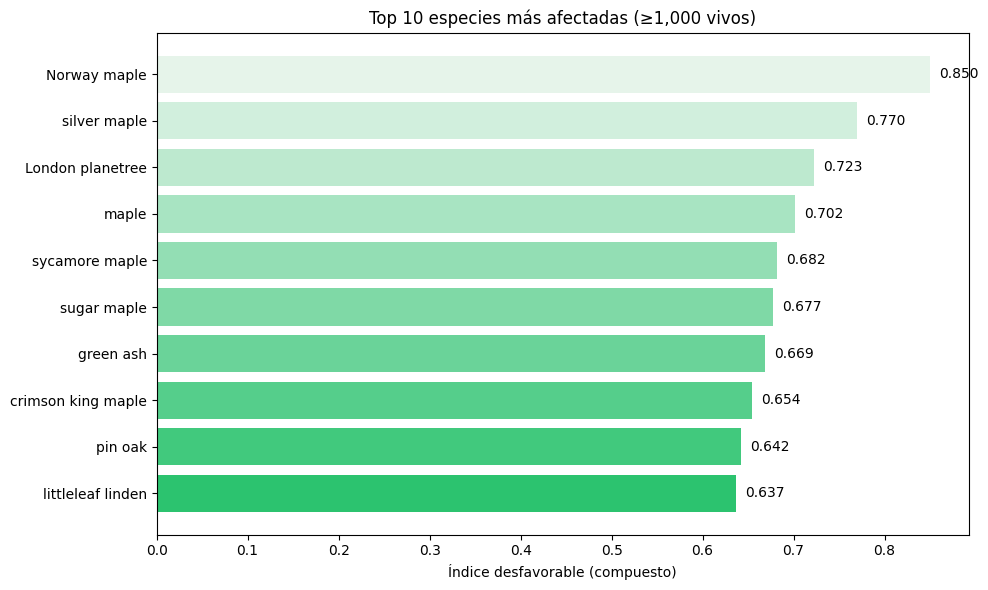

In [ ]:
# ===============================================
# Índice de condiciones desfavorables por especie
# (>=1,000 vivos) + tabla y gráfica (tonos verdes)
# Usando archivo ya subido: Tree_Census.csv
# ===============================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

# 0) Ruta del CSV (ajústala si tu archivo tiene otro nombre o carpeta)
PATH = "Tree_Census.csv"
assert os.path.exists(PATH), f"No encuentro {PATH}. Verifica el nombre/ruta."

# 1) Cargar datos y filtrar árboles vivos
df = pd.read_csv(PATH)
df_alive = df[df["status"] == "Alive"].copy()

# 2) Normalización de columnas usadas
for c in ["health", "sidewalk", "spc_common"]:
    if c not in df_alive.columns:
        raise SystemExit(f"Falta la columna '{c}' en el dataset.")
    df_alive[c] = df_alive[c].astype(str)

# 3) Columnas de problemas físicos (si existen)
prob_cols = [c for c in df_alive.columns if c.startswith(("root_", "trunk_", "branch_"))]
for c in prob_cols:
    df_alive[c] = df_alive[c].astype(str)

# 4) Indicadores por árbol
df_alive["is_poor"] = (df_alive["health"] == "Poor").astype(int)
df_alive["is_fair"] = (df_alive["health"] == "Fair").astype(int)
df_alive["sidewalk"] = df_alive["sidewalk"].fillna("NoDamage")
df_alive["sw_damage"] = (df_alive["sidewalk"] == "Damage").astype(int)

# Algún problema físico (raíz/tronco/ramas) = "Yes" en cualquiera
df_alive["any_problem"] = (df_alive[prob_cols] == "Yes").any(axis=1).astype(int) if prob_cols else 0

# 5) Agregado por especie
agg = (df_alive.groupby("spc_common")
       .agg(
           vivos=("tree_id", "size"),
           poor=("is_poor", "mean"),
           fair=("is_fair", "mean"),
           sidewalk_damage=("sw_damage", "mean"),
           problems=("any_problem", "mean"),
       ).reset_index())

# 6) Índice compuesto (ajusta pesos si lo necesitas)
# Salud: Poor (2.0), Fair (0.5)
# Entorno: Sidewalk damage (0.75)
# Físicos: Problemas raíz/tronco/ramas (0.75)
agg["stress_index"] = (
    2.0 * agg["poor"] +
    0.5 * agg["fair"] +
    0.75 * agg["sidewalk_damage"] +
    0.75 * agg["problems"]
)

# 7) Robustez (>= 1000 vivos), ordenar y mostrar tabla
res = agg[agg["vivos"] >= 1000].copy()
res["%Poor"] = (res["poor"] * 100).round(1)
res["%Fair"] = (res["fair"] * 100).round(1)
res["%Daño banqueta"] = (res["sidewalk_damage"] * 100).round(1)
res["%Problemas físicos"] = (res["problems"] * 100).round(1)
res["Índice desfavorable"] = res["stress_index"].round(3)

cols_show = ["spc_common", "vivos", "%Poor", "%Fair", "%Daño banqueta", "%Problemas físicos", "Índice desfavorable"]
res = res.sort_values(["Índice desfavorable", "%Poor", "%Daño banqueta"], ascending=False)

top10 = res.head(10).reset_index(drop=True).rename(columns={"spc_common": "Especie"})
display(top10)
top10.to_csv("indice_desfavorable_top10.csv", index=False)
print("CSV guardado: indice_desfavorable_top10.csv")

# 8) Gráfica horizontal en tonos verdes
plt.figure(figsize=(10, 6))
y_labels = top10["Especie"]
x_vals = top10["Índice desfavorable"].values

# Paleta verde (claro -> oscuro)
greens = ["#e6f4ea", "#d1efdd", "#bde9cf", "#a8e4c2", "#93deb4",
          "#7fd9a6", "#6ad399", "#55ce8b", "#41c97d", "#2cc36f"]
greens = greens[-len(x_vals):]

plt.barh(y_labels, x_vals, color=greens)
plt.xlabel("Índice desfavorable (compuesto)")
plt.title("Top 10 especies más afectadas (≥1,000 vivos)")

for i, v in enumerate(x_vals):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# (Opcional) Guardar figura:
# plt.savefig("indice_desfavorable_top10.png", dpi=200, bbox_inches="tight")


,Especie,vivos,poor,fair,sidewalk_damage,problems,stress_index,%Poor,%Fair,%Daño banqueta,%Problemas físicos,Índice desfavorable
0,Norway maple,34189,0.110533,0.267981,0.326392,0.333704,0.850127,11.1,26.8,32.6,33.4,0.850
1,silver maple,12277,0.045532,0.183758,0.382097,0.401075,0.770323,4.6,18.4,38.2,40.1,0.770
2,London planetree,87014,0.025260,0.132220,0.395718,0.412911,0.723102,2.5,13.2,39.6,41.3,0.723
3,maple,7080,0.090254,0.244774,0.256780,0.275989,0.702472,9.0,24.5,25.7,27.6,0.702
4,sycamore maple,2731,0.065910,0.205053,0.314537,0.282680,0.682259,6.6,20.5,31.5,28.3,0.682
5,sugar maple,2844,0.082278,0.218003,0.265823,0.272504,0.677303,8.2,21.8,26.6,27.3,0.677
6,green ash,16251,0.026337,0.159929,0.377946,0.336718,0.668636,2.6,16.0,37.8,33.7,0.669
7,crimson king maple,5923,0.075975,0.191964,0.273341,0.267432,0.653512,7.6,19.2,27.3,26.7,0.654
8,pin oak,53185,0.023221,0.120222,0.356059,0.357939,0.642051,2.3,12.0,35.6,35.8,0.642
9,littleleaf linden,29742,0.057831,0.149284,0.311748,0.283303,0.636591,5.8,14.9,31.2,28.3,0.637


CSV guardado: indice_desfavorable_top10.csv


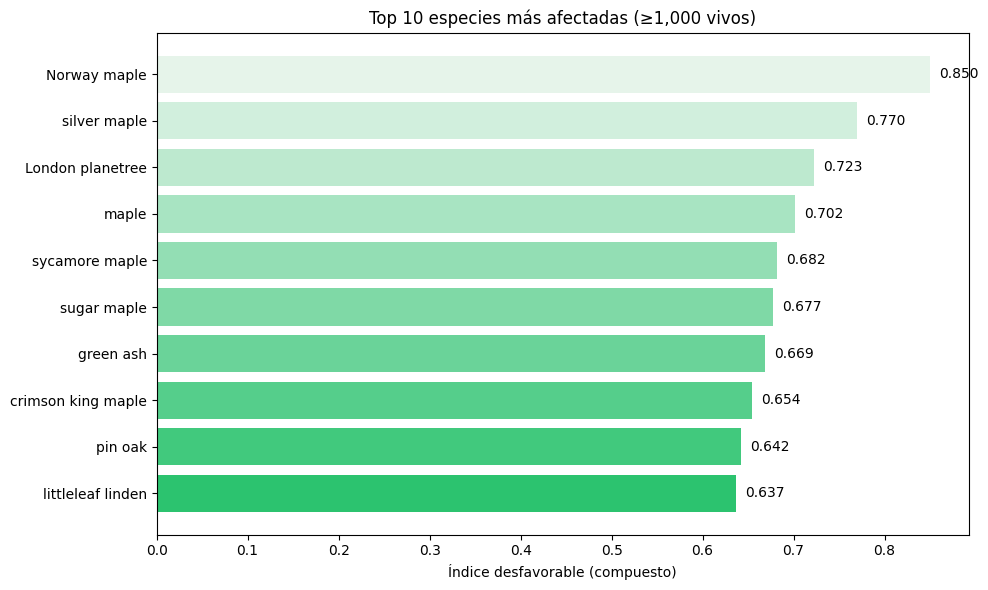

In [ ]:


import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

# 0) Ruta del CSV (ajústala si tu archivo tiene otro nombre o carpeta)
PATH = "Tree_Census.csv"
assert os.path.exists(PATH), f"No encuentro {PATH}. Verifica el nombre/ruta."

# 1) Cargar datos y filtrar árboles vivos
df = pd.read_csv(PATH)
df_alive = df[df["status"] == "Alive"].copy()

# 2) Normalización de columnas usadas
for c in ["health", "sidewalk", "spc_common"]:
    if c not in df_alive.columns:
        raise SystemExit(f"Falta la columna '{c}' en el dataset.")
    df_alive[c] = df_alive[c].astype(str)

# 3) Columnas de problemas físicos (si existen)
prob_cols = [c for c in df_alive.columns if c.startswith(("root_", "trunk_", "branch_"))]
for c in prob_cols:
    df_alive[c] = df_alive[c].astype(str)

# 4) Indicadores por árbol
df_alive["is_poor"] = (df_alive["health"] == "Poor").astype(int)
df_alive["is_fair"] = (df_alive["health"] == "Fair").astype(int)
df_alive["sidewalk"] = df_alive["sidewalk"].fillna("NoDamage")
df_alive["sw_damage"] = (df_alive["sidewalk"] == "Damage").astype(int)

# Algún problema físico (raíz/tronco/ramas) = "Yes" en cualquiera
df_alive["any_problem"] = (df_alive[prob_cols] == "Yes").any(axis=1).astype(int) if prob_cols else 0

# 5) Agregado por especie
agg = (df_alive.groupby("spc_common")
       .agg(
           vivos=("tree_id", "size"),
           poor=("is_poor", "mean"),
           fair=("is_fair", "mean"),
           sidewalk_damage=("sw_damage", "mean"),
           problems=("any_problem", "mean"),
       ).reset_index())

# 6) Índice compuesto (ajusta pesos si lo necesitas)
# Salud: Poor (2.0), Fair (0.5)
# Entorno: Sidewalk damage (0.75)
# Físicos: Problemas raíz/tronco/ramas (0.75)
agg["stress_index"] = (
    2.0 * agg["poor"] +
    0.5 * agg["fair"] +
    0.75 * agg["sidewalk_damage"] +
    0.75 * agg["problems"]
)

# 7) Robustez (>= 1000 vivos), ordenar y mostrar tabla
res = agg[agg["vivos"] >= 1000].copy()
res["%Poor"] = (res["poor"] * 100).round(1)
res["%Fair"] = (res["fair"] * 100).round(1)
res["%Daño banqueta"] = (res["sidewalk_damage"] * 100).round(1)
res["%Problemas físicos"] = (res["problems"] * 100).round(1)
res["Índice desfavorable"] = res["stress_index"].round(3)

cols_show = ["spc_common", "vivos", "%Poor", "%Fair", "%Daño banqueta", "%Problemas físicos", "Índice desfavorable"]
res = res.sort_values(["Índice desfavorable", "%Poor", "%Daño banqueta"], ascending=False)

top10 = res.head(10).reset_index(drop=True).rename(columns={"spc_common": "Especie"})
display(top10)
top10.to_csv("indice_desfavorable_top10.csv", index=False)
print("CSV guardado: indice_desfavorable_top10.csv")

# 8) Gráfica horizontal en tonos verdes
plt.figure(figsize=(10, 6))
y_labels = top10["Especie"]
x_vals = top10["Índice desfavorable"].values

# Paleta verde (claro -> oscuro)
greens = ["#e6f4ea", "#d1efdd", "#bde9cf", "#a8e4c2", "#93deb4",
          "#7fd9a6", "#6ad399", "#55ce8b", "#41c97d", "#2cc36f"]
greens = greens[-len(x_vals):]

plt.barh(y_labels, x_vals, color=greens)
plt.xlabel("Índice desfavorable (compuesto)")
plt.title("Top 10 especies más afectadas (≥1,000 vivos)")

for i, v in enumerate(x_vals):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



,Especie,vivos,%Good,%Poor,%Fair,%Daño banqueta,%Problemas físicos,Índice (menor=mejor)
0,eastern redcedar,1101,85.921889,3.5,10.5,14.6,6.8,0.284
1,crab apple,3527,82.137794,4.1,13.8,13.0,9.5,0.319
2,cherry,29279,83.766522,4.5,11.8,14.5,9.1,0.325
3,golden raintree,3719,83.328852,3.2,13.4,16.3,10.6,0.333
4,sawtooth oak,2244,87.655971,2.1,10.2,18.5,13.8,0.336
5,Japanese tree lilac,4568,79.794221,4.8,15.4,14.4,8.2,0.343
6,Cornelian cherry,1066,82.645403,4.5,12.9,16.5,8.9,0.345
7,Japanese maple,1130,78.849558,5.0,16.1,14.2,7.7,0.346
8,purple-leaf plum,6879,79.153947,5.0,15.9,13.5,9.1,0.348
9,Kentucky coffeetree,3364,84.274673,4.0,11.7,18.0,10.0,0.350


CSV guardado: especies_mas_aptas_top10.csv


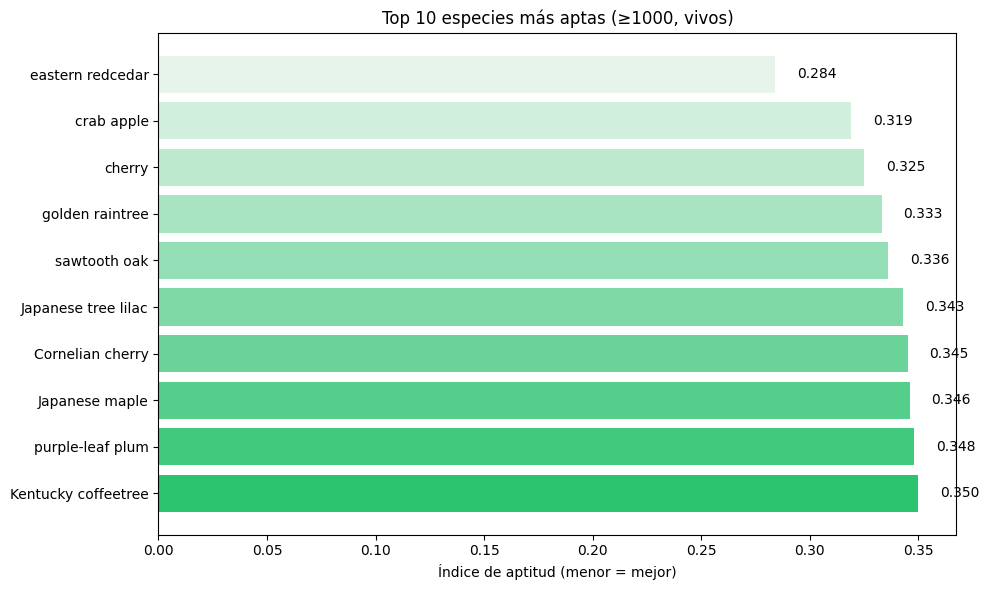

In [ ]:
# ===============================================
# Especies "más aptas" para NYC (menor índice)
# Dataset ya subido: Tree_Census.csv
# Considera: salud + daño en banqueta + problemas físicos
# ===============================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

# ---------- Parámetros (puedes ajustarlos) ----------
PATH = "Tree_Census.csv"   # cambia si tu archivo tiene otro nombre
UMBRAL_VIVOS = 1000        # robustez de muestra
# Pesos del índice (menor = mejor / más apta)
W_POOR = 2.0
W_FAIR = 0.5
W_SIDEWALK = 0.75
W_PROBLEMS = 0.75
# Traducción opcional a español
USE_SPANISH_NAMES = False
SPANISH = {
    "eastern redcedar": "enebro de Virginia",
    "crab apple": "manzano silvestre (ornamental)",
    "cherry": "cerezo",
    "golden raintree": "árbol de lluvia dorada",
    "sawtooth oak": "roble de dientes de sierra",
    "Japanese tree lilac": "lila arbórea japonesa",
    "Cornelian cherry": "cornejo macho",
    "Japanese maple": "arce japonés",
    "purple-leaf plum": "ciruelo de hoja púrpura",
    "Kentucky coffeetree": "árbol del café de Kentucky",
    "hawthorn": "espino",
    "serviceberry": "amelanchier (guillomo)"
}
# -----------------------------------------------------

assert os.path.exists(PATH), f"No encuentro {PATH}. Verifica el nombre/ruta."
df = pd.read_csv(PATH)

# 1) Filtrar árboles vivos
df_alive = df[df["status"] == "Alive"].copy()

# 2) Normalización de columnas
for c in ["health", "sidewalk", "spc_common"]:
    if c not in df_alive.columns:
        raise SystemExit(f"Falta la columna '{c}' en el dataset.")
    df_alive[c] = df_alive[c].astype(str)

# 3) Columnas de problemas físicos si existen
prob_cols = [c for c in df_alive.columns if c.startswith(("root_", "trunk_", "branch_"))]
for c in prob_cols:
    df_alive[c] = df_alive[c].astype(str)

# 4) Indicadores por árbol
df_alive["is_poor"] = (df_alive["health"] == "Poor").astype(int)
df_alive["is_fair"] = (df_alive["health"] == "Fair").astype(int)
df_alive["sidewalk"] = df_alive["sidewalk"].fillna("NoDamage")
df_alive["sw_damage"] = (df_alive["sidewalk"] == "Damage").astype(int)
df_alive["any_problem"] = (df_alive[prob_cols] == "Yes").any(axis=1).astype(int) if prob_cols else 0

# 5) Agregado por especie
agg = (df_alive.groupby("spc_common")
       .agg(
           vivos=("tree_id", "size"),
           poor=("is_poor", "mean"),
           fair=("is_fair", "mean"),
           sidewalk_damage=("sw_damage", "mean"),
           problems=("any_problem", "mean"),
       )
       .reset_index())

# 6) Índice de aptitud (menor = mejor)
#    Menor Poor/Fair/Daño/Problemas => más apta
agg["fitness_index"] = (
    W_POOR * agg["poor"] +
    W_FAIR * agg["fair"] +
    W_SIDEWALK * agg["sidewalk_damage"] +
    W_PROBLEMS * agg["problems"]
)

# 7) Robustez, métricas legibles y orden
res = agg[agg["vivos"] >= UMBRAL_VIVOS].copy()
res["%Good"] = (1 - res["poor"] - res["fair"]) * 100
res["%Poor"] = (res["poor"] * 100).round(1)
res["%Fair"] = (res["fair"] * 100).round(1)
res["%Daño banqueta"] = (res["sidewalk_damage"] * 100).round(1)
res["%Problemas físicos"] = (res["problems"] * 100).round(1)
res["Índice (menor=mejor)"] = res["fitness_index"].round(3)

# 8) Top 10 "más aptas"
top10 = res.sort_values(["fitness_index", "poor", "sidewalk_damage"],
                        ascending=[True, True, True]).head(10).reset_index(drop=True)

# Traducción opcional
if USE_SPANISH_NAMES:
    top10.insert(0, "Especie (español)", top10["spc_common"].map(SPANISH).fillna(top10["spc_common"]))
    top10 = top10.rename(columns={"spc_common": "Especie (inglés)"})
else:
    top10 = top10.rename(columns={"spc_common": "Especie"})

cols_show = [c for c in ["Especie (español)", "Especie (inglés)", "Especie"] if c in top10.columns] \
            + ["vivos", "%Good", "%Poor", "%Fair", "%Daño banqueta", "%Problemas físicos", "Índice (menor=mejor)"]
top10 = top10[cols_show]

display(top10)
top10.to_csv("especies_mas_aptas_top10.csv", index=False)
print("CSV guardado: especies_mas_aptas_top10.csv")

# 9) Gráfica horizontal en tonos verdes
plt.figure(figsize=(10, 6))
names_col = "Especie (español)" if "Especie (español)" in top10.columns else ("Especie (inglés)" if "Especie (inglés)" in top10.columns else "Especie")
y_labels = top10[names_col]
x_vals = top10["Índice (menor=mejor)"].values

greens = ["#e6f4ea", "#d1efdd", "#bde9cf", "#a8e4c2", "#93deb4",
          "#7fd9a6", "#6ad399", "#55ce8b", "#41c97d", "#2cc36f"]
greens = greens[-len(x_vals):]

plt.barh(y_labels, x_vals, color=greens)
plt.xlabel("Índice de aptitud (menor = mejor)")
plt.title("Top 10 especies más aptas (≥{}, vivos)".format(UMBRAL_VIVOS))
for i, v in enumerate(x_vals):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
)


,Especie (español),Especie (inglés),vivos,n_on,%Good (std borough),%Good (std DBH),%Good en banqueta,%Good sin guards,%Good sin steward,%Poor (std borough),%Fair (std borough),%Daño banqueta,%Problemas físicos,Índice aptitud
0,roble de dientes de sierra,sawtooth oak,2244,2188,88.7,88.9,87.6,0.0,0.0,2.2,9.1,18.5,13.8,54.6
1,árbol del café de Kentucky,Kentucky coffeetree,3364,3197,84.3,85.3,84.8,0.0,0.0,4.1,11.6,18.0,10.0,52.0
2,cerezo,cherry,29279,28703,83.0,84.2,83.8,0.0,0.0,4.6,12.3,14.5,9.1,51.8
3,árbol de lluvia dorada,golden raintree,3719,3619,83.3,86.0,83.8,0.0,0.0,3.2,13.4,16.3,10.6,51.8
4,zelkova japonesa,Japanese zelkova,29258,28339,86.9,88.3,86.4,0.0,0.0,2.6,10.5,25.2,20.5,51.1
5,Amur maackia,Amur maackia,2197,2163,82.7,85.7,82.8,0.0,0.0,4.5,12.8,17.8,10.4,50.9
6,roble blanco de pantano,swamp white oak,6598,6288,82.6,86.2,82.3,0.0,0.0,4.0,13.4,18.6,10.7,50.6
7,manzano silvestre (ornamental),crab apple,3527,3225,82.1,79.4,81.7,0.0,0.0,4.0,13.9,13.0,9.5,50.5
8,roble inglés,English oak,1644,1579,82.5,85.8,82.7,0.0,0.0,2.7,14.8,19.9,13.4,50.1
9,olmo chino,Chinese elm,5345,5157,84.9,85.2,84.3,0.0,0.0,3.1,12.0,22.8,19.8,49.8


CSV guardado: aptitud_urbana_top10.csv


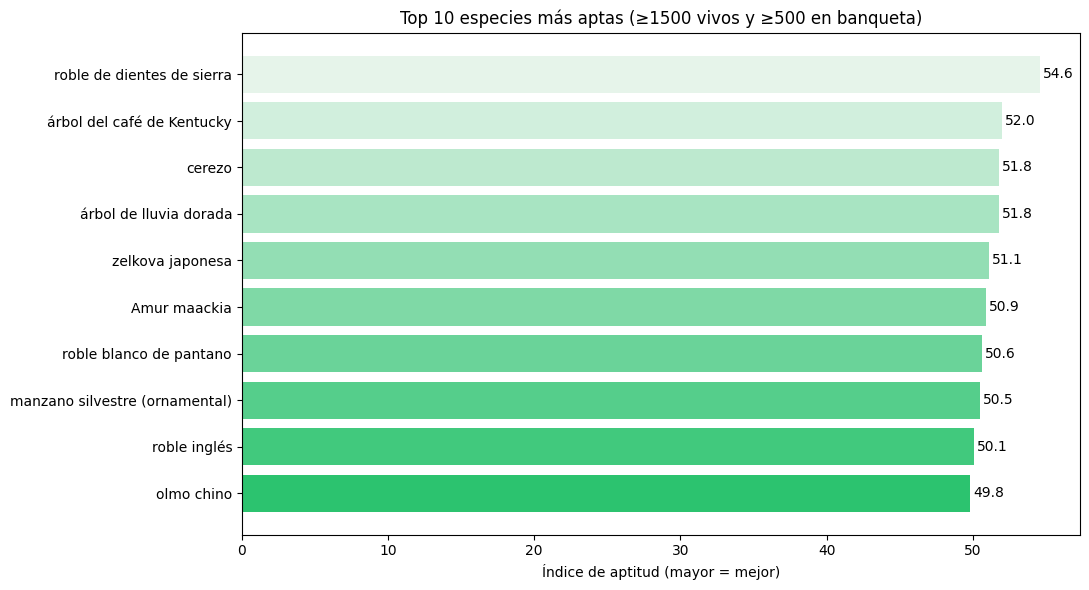

In [ ]:


# -------- Parámetros ajustables --------
PATH = "Tree_Census.csv"
UMBRAL_VIVOS = 1500
UMBRAL_ONCURB = 500

# Pesos del índice (mayor = mejor aptitud)
W_GOOD_BORO = 0.30
W_GOOD_DBH = 0.15
W_GOOD_ONCURB = 0.25
W_GOOD_NOGUARD = 0.15
W_GOOD_NOSTEWARD = 0.15
W_POOR_BORO = -0.25
W_FAIR_BORO = -0.10
W_SIDEWALK = -0.20
W_PROBLEMS = -0.15

USE_SPANISH_NAMES = True
TRAD_ES = {
    "sawtooth oak": "roble de dientes de sierra",
    "Kentucky coffeetree": "árbol del café de Kentucky",
    "Japanese zelkova": "zelkova japonesa",
    "cherry": "cerezo",
    "golden raintree": "árbol de lluvia dorada",
    "Amur maackia": "Amur maackia",
    "swamp white oak": "roble blanco de pantano",
    "Chinese elm": "olmo chino",
    "crab apple": "manzano silvestre (ornamental)",
    "English oak": "roble inglés",
    "eastern redcedar": "enebro de Virginia",
    "Japanese tree lilac": "lila arbórea japonesa",
    "Cornelian cherry": "cornejo macho",
    "Japanese maple": "arce japonés",
    "purple-leaf plum": "ciruelo de hoja púrpura",
    "honeylocust": "acacia de tres espinas",
    "pin oak": "roble de pantano",
    "London planetree": "plátano de Londres",
    "silver linden": "tilo plateado",
    "sweetgum": "liquidámbar",
    "serviceberry": "amelanchier (guillomo)",
    "hawthorn": "espino",
    "ginkgo": "ginkgo",
    "red maple": "arce rojo",
}
# --------------------------------------

assert os.path.exists(PATH), f"No encuentro {PATH}. Verifica nombre/ruta."
df = pd.read_csv(PATH)

# 1) Filtrar árboles vivos
df_alive = df[df["status"] == "Alive"].copy()

def ensure_str(col):
    if col not in df_alive.columns:
        raise SystemExit(f"Falta la columna requerida: '{col}'")
    df_alive[col] = df_alive[col].astype(str)

# 2) Normalizar columnas usadas
for c in ["health", "sidewalk", "steward", "guards", "spc_common", "borough"]:
    ensure_str(c)

# curb_loc puede faltar
if "curb_loc" in df_alive.columns:
    df_alive["curb_loc"] = df_alive["curb_loc"].astype(str)
else:
    df_alive["curb_loc"] = "OffsetFromCurb"

# 3) Columnas de problemas físicos (si existen)
prob_cols = [c for c in df_alive.columns if c.startswith(("root_", "trunk_", "branch_"))]
for c in prob_cols:
    df_alive[c] = df_alive[c].astype(str)

# 4) Bins de DBH (diámetro) -> convertir a string para evitar problemas de Categorical
bins = [0,6,12,18,24,30,1000]
labels = ['0-6','7-12','13-18','19-24','25-30','31+']
df_alive["dbh_bin"] = pd.cut(
    df_alive["tree_dbh"].fillna(-1).clip(lower=0),
    bins=bins, labels=labels, include_lowest=True
).astype(str)  # <--- clave para evitar el TypeError

# 5) Indicadores por árbol
df_alive["is_good"] = (df_alive["health"] == "Good").astype(int)
df_alive["is_fair"] = (df_alive["health"] == "Fair").astype(int)
df_alive["is_poor"] = (df_alive["health"] == "Poor").astype(int)
df_alive["sidewalk"] = df_alive["sidewalk"].fillna("NoDamage")
df_alive["sw_damage"] = (df_alive["sidewalk"] == "Damage").astype(int)
df_alive["is_oncurb"] = (df_alive["curb_loc"] == "OnCurb").astype(int)
df_alive["no_guard"] = (df_alive["guards"] == "None").astype(int)
df_alive["no_steward"] = (df_alive["steward"] == "None").astype(int)
df_alive["any_problem"] = (df_alive[prob_cols] == "Yes").any(axis=1).astype(int) if prob_cols else 0

# 6) Estandarización por borough (observed=True para silenciar FutureWarning)
city_boro_share = df_alive.groupby("borough", observed=True).size()
city_boro_share = (city_boro_share / city_boro_share.sum()).rename("w_boro").reset_index()

sp_boro = (df_alive.groupby(["spc_common","borough"], observed=True)
           .agg(good=("is_good","mean"),
                fair=("is_fair","mean"),
                poor=("is_poor","mean"))
           .reset_index())

sp_boro = sp_boro.merge(city_boro_share, on="borough", how="right")
# Rellenar solo columnas numéricas
for col in ["good","fair","poor","w_boro"]:
    sp_boro[col] = sp_boro[col].fillna(0)

sp_boro["good_w"] = sp_boro["good"] * sp_boro["w_boro"]
sp_boro["fair_w"] = sp_boro["fair"] * sp_boro["w_boro"]
sp_boro["poor_w"] = sp_boro["poor"] * sp_boro["w_boro"]

boro_std = sp_boro.groupby("spc_common", observed=True).agg(
    good_boro=("good_w","sum"),
    fair_boro=("fair_w","sum"),
    poor_boro=("poor_w","sum")
).reset_index()

# 7) Estandarización por tamaño (DBH) — ahora dbh_bin es str
city_dbh_share = df_alive.groupby("dbh_bin", observed=True).size()
city_dbh_share = (city_dbh_share / city_dbh_share.sum()).rename("w_dbh").reset_index()

sp_dbh = (df_alive.groupby(["spc_common","dbh_bin"], observed=True)
          .agg(good=("is_good","mean"),
               fair=("is_fair","mean"),
               poor=("is_poor","mean"))
          .reset_index())

sp_dbh = sp_dbh.merge(city_dbh_share, on="dbh_bin", how="right")
for col in ["good","fair","poor","w_dbh"]:
    sp_dbh[col] = sp_dbh[col].fillna(0)

sp_dbh["good_w"] = sp_dbh["good"] * sp_dbh["w_dbh"]
sp_dbh["fair_w"] = sp_dbh["fair"] * sp_dbh["w_dbh"]
sp_dbh["poor_w"] = sp_dbh["poor"] * sp_dbh["w_dbh"]

dbh_std = sp_dbh.groupby("spc_common", observed=True).agg(
    good_dbh=("good_w","sum"),
    fair_dbh=("fair_w","sum"),
    poor_dbh=("poor_w","sum")
).reset_index()

# 8) Métricas de tolerancia calle
sp_oncurb = (df_alive[df_alive["is_oncurb"]==1]
             .groupby("spc_common", observed=True)
             .agg(good_on=("is_good","mean"),
                  n_on=("spc_common","size"))
             .reset_index())

sp_noguard = (df_alive[df_alive["no_guard"]==1]
              .groupby("spc_common", observed=True)
              .agg(good_noguard=("is_good","mean"),
                   n_noguard=("spc_common","size"))
              .reset_index())

sp_nosteward = (df_alive[df_alive["no_steward"]==1]
                .groupby("spc_common", observed=True)
                .agg(good_nosteward=("is_good","mean"),
                     n_nosteward=("spc_common","size"))
                .reset_index())

# 9) Penalizaciones + total vivos
sp_pen = (df_alive.groupby("spc_common", observed=True)
          .agg(sidewalk_damage=("sw_damage","mean"),
               problems=("any_problem","mean"),
               vivos=("spc_common","size"))
          .reset_index())

# 10) Unir todo
sp_all = (sp_pen
          .merge(boro_std, on="spc_common", how="left")
          .merge(dbh_std, on="spc_common", how="left")
          .merge(sp_oncurb, on="spc_common", how="left")
          .merge(sp_noguard, on="spc_common", how="left")
          .merge(sp_nosteward, on="spc_common", how="left"))

# Rellenar solo numéricos
num_cols = ["good_boro","fair_boro","poor_boro",
            "good_dbh","fair_dbh","poor_dbh",
            "good_on","n_on","good_noguard","n_noguard","good_nosteward","n_nosteward",
            "sidewalk_damage","problems","vivos"]
for col in num_cols:
    if col in sp_all.columns:
        sp_all[col] = sp_all[col].fillna(0)

# 11) Filtros de robustez
mask = (sp_all["vivos"] >= UMBRAL_VIVOS) & (sp_all["n_on"] >= UMBRAL_ONCURB)
sp_all = sp_all[mask].copy()

# 12) Índice de aptitud (mayor = mejor)
sp_all["aptitude_score"] = (
    W_GOOD_BORO   * sp_all["good_boro"]    +
    W_GOOD_DBH    * sp_all["good_dbh"]     +
    W_GOOD_ONCURB * sp_all["good_on"]      +
    W_GOOD_NOGUARD* sp_all["good_noguard"] +
    W_GOOD_NOSTEWARD * sp_all["good_nosteward"] +
    W_POOR_BORO   * sp_all["poor_boro"]    +
    W_FAIR_BORO   * sp_all["fair_boro"]    +
    W_SIDEWALK    * sp_all["sidewalk_damage"] +
    W_PROBLEMS    * sp_all["problems"]
)

# 13) Tabla final
def pct(x): return (x*100).round(1)
tabla = sp_all.copy()
tabla["Índice aptitud"] = (tabla["aptitude_score"]*100).round(1)
tabla["%Good (std borough)"] = pct(tabla["good_boro"])
tabla["%Good (std DBH)"] = pct(tabla["good_dbh"])
tabla["%Good en banqueta"] = pct(tabla["good_on"])
tabla["%Good sin guards"] = pct(tabla["good_noguard"])
tabla["%Good sin steward"] = pct(tabla["good_nosteward"])
tabla["%Poor (std borough)"] = pct(tabla["poor_boro"])
tabla["%Fair (std borough)"] = pct(tabla["fair_boro"])
tabla["%Daño banqueta"] = pct(tabla["sidewalk_damage"])
tabla["%Problemas físicos"] = pct(tabla["problems"])

tabla = tabla.sort_values("Índice aptitud", ascending=False).reset_index(drop=True)

# Top 10
top10 = tabla[["spc_common","vivos","n_on",
               "%Good (std borough)","%Good (std DBH)","%Good en banqueta",
               "%Good sin guards","%Good sin steward",
               "%Poor (std borough)","%Fair (std borough)",
               "%Daño banqueta","%Problemas físicos",
               "Índice aptitud"]].head(10).copy()

if USE_SPANISH_NAMES:
    top10.insert(0, "Especie (español)", top10["spc_common"].map(TRAD_ES).fillna(top10["spc_common"]))
    top10 = top10.rename(columns={"spc_common": "Especie (inglés)"})
else:
    top10 = top10.rename(columns={"spc_common": "Especie"})

display(top10)
top10.to_csv("aptitud_urbana_top10.csv", index=False)
print("CSV guardado: aptitud_urbana_top10.csv")

# 14) Gráfica horizontal (tonos verdes)
plt.figure(figsize=(11, 6))
name_col = "Especie (español)" if USE_SPANISH_NAMES else ("Especie" if "Especie" in top10.columns else "Especie (inglés)")
y = top10[name_col]
x = top10["Índice aptitud"].values

greens = ["#e6f4ea", "#d1efdd", "#bde9cf", "#a8e4c2", "#93deb4",
          "#7fd9a6", "#6ad399", "#55ce8b", "#41c97d", "#2cc36f"]
greens = greens[-len(x):]

plt.barh(y, x, color=greens)
plt.xlabel("Índice de aptitud (mayor = mejor)")
plt.title(f"Top 10 especies más aptas (≥{UMBRAL_VIVOS} vivos y ≥{UMBRAL_ONCURB} en banqueta)")
for i, v in enumerate(x):
    plt.text(v + 0.2, i, f"{v:.1f}", va="center")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Muertos totales: 13961 | Muertos con especie conocida: 1

Top 10 especies con MAYOR prioridad de reemplazo (proxy de mortalidad):


,Especie (español),Especie (inglés),vivos,%Poor,%Fair,%Daño banqueta,%Problemas físicos,Score reemplazo
0,arce de Noruega,Norway maple,34189,11.1,26.8,32.6,33.4,97.5
1,silver maple,silver maple,12277,4.6,18.4,38.2,40.1,90.4
2,London planetree,London planetree,87014,2.5,13.2,39.6,41.3,85.6
3,arce (genérico),maple,7080,9.0,24.5,25.7,27.6,80.5
4,green ash,green ash,16251,2.6,16.0,37.8,33.7,79.6
5,arce sicómoro,sycamore maple,2731,6.6,20.5,31.5,28.3,79.6
6,arce de azúcar,sugar maple,2844,8.2,21.8,26.6,27.3,77.9
7,pin oak,pin oak,53185,2.3,12.0,35.6,35.8,76.1
8,arce 'Crimson King',crimson king maple,5923,7.6,19.2,27.3,26.7,75.4
9,honeylocust,honeylocust,64263,1.9,13.3,35.6,34.5,74.9


CSV guardado: prioridad_reemplazo_top10.csv


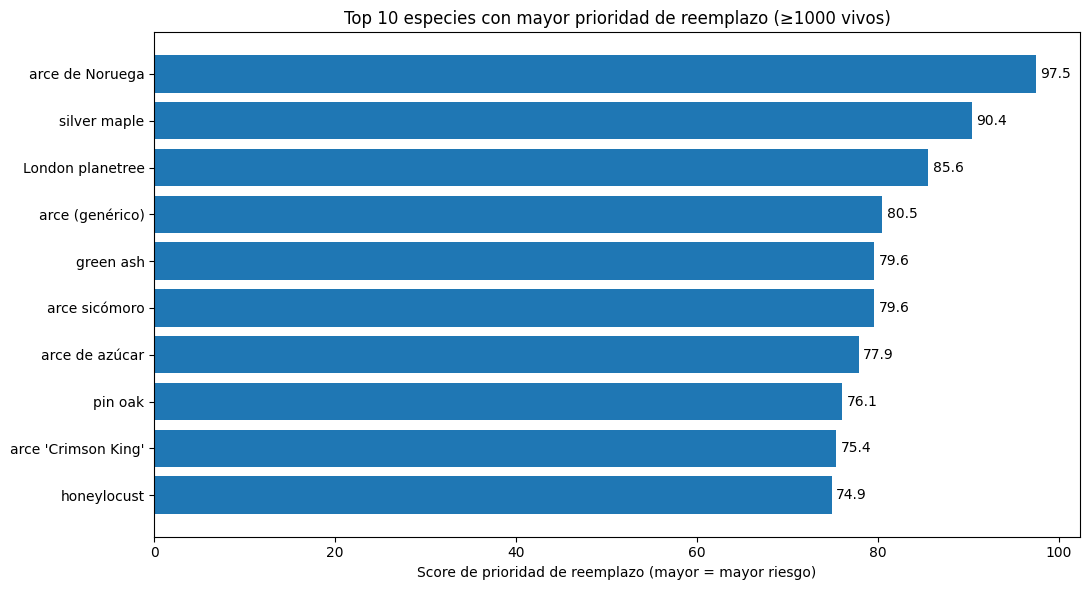

In [ ]:
# ============================================================
# Prioridad de reemplazo por especie (proxy de mortalidad)
# Dataset ya presente: Tree_Census.csv
# - NO hay especie para casi todos los "Dead", así que usamos un proxy:
#   Score = 2.0*Poor + 0.6*Fair + 1.0*Daño_banqueta + 0.8*Problemas_físicos
# - Reporta Top 10 (muestra robusta: >= 1,000 vivos)
# - Entrega tabla y gráfica horizontal
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -------- Parámetros (puedes ajustarlos) --------
PATH = "Tree_Census.csv"   # cambia si tu archivo tiene otra ruta/nombre
UMBRAL_VIVOS = 1000        # robustez de muestra

# Pesos del score de reemplazo (mayor = mayor prioridad)
W_POOR = 2.0
W_FAIR = 0.6
W_SIDEWALK = 1.0
W_PROBLEMS = 0.8

# Mostrar nombres en español (si se conoce) en tabla y gráfica
USE_SPANISH_NAMES = True
TRAD_ES = {
    "Norway maple": "arce de Noruega",
    "maple": "arce (genérico)",
    "horse chestnut": "castaño de Indias",
    "sugar maple": "arce de azúcar",
    "crimson king maple": "arce 'Crimson King'",
    "eastern redbud": "ciclamor del Este",
    "sycamore maple": "arce sicómoro",
    "dawn redwood": "metasecuoya",
    "serviceberry": "amelanchier (guillomo)",
    "tulip-poplar": "tulípero",
    "katsura tree": "katsura",
    "Turkish hazelnut": "avellano turco",
    "Atlantic white cedar": "cedro blanco atlántico",
    "catalpa": "catalpa",
    "paperbark maple": "arce de corteza de papel",
    "Japanese snowbell": "estefanoto japonés",
    "American beech": "haya americana",
    "tree of heaven": "ailanto",
    "Kentucky yellowwood": "yellowwood de Kentucky",
    # Agrega más si lo deseas…
}
# -----------------------------------------------

assert os.path.exists(PATH), f"No encuentro {PATH}. Verifica el nombre/ruta."
df = pd.read_csv(PATH)

# 1) Diagnóstico: muertos con especie conocida (para documentar limitación)
dead_total = int((df["status"] == "Dead").sum())
dead_with_species = int(df[(df["status"] == "Dead") &
                           df["spc_common"].notna() &
                           (df["spc_common"] != "Unknown")].shape[0])
print(f"Muertos totales: {dead_total} | Muertos con especie conocida: {dead_with_species}")

# 2) Nos enfocamos en vivos para medir riesgo
alive = df[df["status"] == "Alive"].copy()

# Normalizar columnas clave
for c in ["health", "sidewalk", "spc_common"]:
    if c not in alive.columns:
        raise SystemExit(f"Falta la columna requerida: '{c}'")
    alive[c] = alive[c].astype(str)

# Columnas de problemas físicos (si existen)
prob_cols = [c for c in alive.columns if c.startswith(("root_", "trunk_", "branch_"))]
for c in prob_cols:
    alive[c] = alive[c].astype(str)

# 3) Indicadores por árbol
alive["is_poor"] = (alive["health"] == "Poor").astype(int)
alive["is_fair"] = (alive["health"] == "Fair").astype(int)
alive["sidewalk"] = alive["sidewalk"].fillna("NoDamage")
alive["sw_damage"] = (alive["sidewalk"] == "Damage").astype(int)
alive["any_problem"] = (alive[prob_cols] == "Yes").any(axis=1).astype(int) if prob_cols else 0

# 4) Agregado por especie
sp = (alive.groupby("spc_common")
      .agg(
          vivos=("tree_id", "size"),
          poor=("is_poor", "mean"),
          fair=("is_fair", "mean"),
          sidewalk_damage=("sw_damage", "mean"),
          problems=("any_problem", "mean"),
      )
      .reset_index())

# 5) Score de prioridad de reemplazo (proxy de mortalidad)
sp["repl_score"] = (
    W_POOR * sp["poor"] +
    W_FAIR * sp["fair"] +
    W_SIDEWALK * sp["sidewalk_damage"] +
    W_PROBLEMS * sp["problems"]
)

# 6) Filtro de robustez y orden
robust = sp[sp["vivos"] >= UMBRAL_VIVOS].copy()
robust["%Poor"] = (robust["poor"] * 100).round(1)
robust["%Fair"] = (robust["fair"] * 100).round(1)
robust["%Daño banqueta"] = (robust["sidewalk_damage"] * 100).round(1)
robust["%Problemas físicos"] = (robust["problems"] * 100).round(1)
robust["Score reemplazo"] = (robust["repl_score"] * 100).round(1)

top10 = robust.sort_values(["repl_score", "poor", "sidewalk_damage"], ascending=False).head(10).copy()

# Traducción opcional
if USE_SPANISH_NAMES:
    top10.insert(0, "Especie (español)", top10["spc_common"].map(TRAD_ES).fillna(top10["spc_common"]))
    top10 = top10.rename(columns={"spc_common": "Especie (inglés)"})
else:
    top10 = top10.rename(columns={"spc_common": "Especie"})

cols_show = [c for c in ["Especie (español)", "Especie (inglés)", "Especie"] if c in top10.columns] + \
            ["vivos", "%Poor", "%Fair", "%Daño banqueta", "%Problemas físicos", "Score reemplazo"]
top10 = top10[cols_show].reset_index(drop=True)

print("\nTop 10 especies con MAYOR prioridad de reemplazo (proxy de mortalidad):")
display(top10)

# Guardar CSV
top10.to_csv("prioridad_reemplazo_top10.csv", index=False)
print("CSV guardado: prioridad_reemplazo_top10.csv")

# 7) Gráfica horizontal (matplotlib, una sola figura)
plt.figure(figsize=(11, 6))
name_col = "Especie (español)" if USE_SPANISH_NAMES else ("Especie" if "Especie" in top10.columns else "Especie (inglés)")
y_labels = top10[name_col]
x_vals = top10["Score reemplazo"].values

plt.barh(y_labels, x_vals)  # sin forzar colores; usa los de Matplotlib por defecto
plt.xlabel("Score de prioridad de reemplazo (mayor = mayor riesgo)")
plt.title(f"Top 10 especies con mayor prioridad de reemplazo (≥{UMBRAL_VIVOS} vivos)")
for i, v in enumerate(x_vals):
    plt.text(v + 0.5, i, f"{v:.1f}", va="center")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Muertos totales: 13961 | Muertos con especie conocida: 1

Top 10 especies con MAYOR prioridad de reemplazo (proxy de mortalidad):


,Especie (español),Especie (inglés),vivos,%Poor,%Fair,%Daño banqueta,%Problemas físicos,Score reemplazo
0,arce de Noruega,Norway maple,34189,11.1,26.8,32.6,33.4,97.5
1,silver maple,silver maple,12277,4.6,18.4,38.2,40.1,90.4
2,London planetree,London planetree,87014,2.5,13.2,39.6,41.3,85.6
3,arce (genérico),maple,7080,9.0,24.5,25.7,27.6,80.5
4,green ash,green ash,16251,2.6,16.0,37.8,33.7,79.6
5,arce sicómoro,sycamore maple,2731,6.6,20.5,31.5,28.3,79.6
6,arce de azúcar,sugar maple,2844,8.2,21.8,26.6,27.3,77.9
7,pin oak,pin oak,53185,2.3,12.0,35.6,35.8,76.1
8,arce 'Crimson King',crimson king maple,5923,7.6,19.2,27.3,26.7,75.4
9,honeylocust,honeylocust,64263,1.9,13.3,35.6,34.5,74.9


CSV guardado: prioridad_reemplazo_top10.csv


/tmp/ipython-input-3989623231.py:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  browns = plt.cm.get_cmap('tab20', len(x_vals))


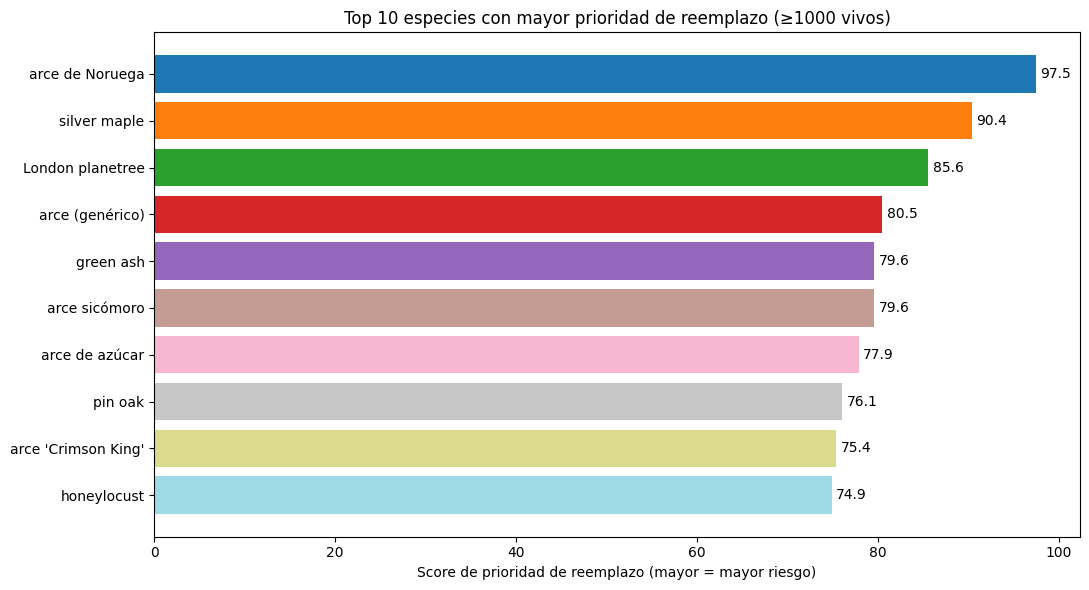

In [ ]:

PATH = "Tree_Census.csv"   # cambia si tu archivo tiene otra ruta/nombre
UMBRAL_VIVOS = 1000        # robustez de muestra

# Pesos del score de reemplazo (mayor = mayor prioridad)
W_POOR = 2.0
W_FAIR = 0.6
W_SIDEWALK = 1.0
W_PROBLEMS = 0.8

# Mostrar nombres en español (si se conoce) en tabla y gráfica
USE_SPANISH_NAMES = True
TRAD_ES = {
    "Norway maple": "arce de Noruega",
    "maple": "arce (genérico)",
    "horse chestnut": "castaño de Indias",
    "sugar maple": "arce de azúcar",
    "crimson king maple": "arce 'Crimson King'",
    "eastern redbud": "ciclamor del Este",
    "sycamore maple": "arce sicómoro",
    "dawn redwood": "metasecuoya",
    "serviceberry": "amelanchier (guillomo)",
    "tulip-poplar": "tulípero",
    "katsura tree": "katsura",
    "Turkish hazelnut": "avellano turco",
    "Atlantic white cedar": "cedro blanco atlántico",
    "catalpa": "catalpa",
    "paperbark maple": "arce de corteza de papel",
    "Japanese snowbell": "estefanoto japonés",
    "American beech": "haya americana",
    "tree of heaven": "ailanto",
    "Kentucky yellowwood": "yellowwood de Kentucky",
    # Agrega más si lo deseas…
}
# -----------------------------------------------

assert os.path.exists(PATH), f"No encuentro {PATH}. Verifica el nombre/ruta."
df = pd.read_csv(PATH)

# 1) Diagnóstico: muertos con especie conocida (para documentar limitación)
dead_total = int((df["status"] == "Dead").sum())
dead_with_species = int(df[(df["status"] == "Dead") &
                           df["spc_common"].notna() &
                           (df["spc_common"] != "Unknown")].shape[0])
print(f"Muertos totales: {dead_total} | Muertos con especie conocida: {dead_with_species}")

# 2) Nos enfocamos en vivos para medir riesgo
alive = df[df["status"] == "Alive"].copy()

# Normalizar columnas clave
for c in ["health", "sidewalk", "spc_common"]:
    if c not in alive.columns:
        raise SystemExit(f"Falta la columna requerida: '{c}'")
    alive[c] = alive[c].astype(str)

# Columnas de problemas físicos (si existen)
prob_cols = [c for c in alive.columns if c.startswith(("root_", "trunk_", "branch_"))]
for c in prob_cols:
    alive[c] = alive[c].astype(str)

# 3) Indicadores por árbol
alive["is_poor"] = (alive["health"] == "Poor").astype(int)
alive["is_fair"] = (alive["health"] == "Fair").astype(int)
alive["sidewalk"] = alive["sidewalk"].fillna("NoDamage")
alive["sw_damage"] = (alive["sidewalk"] == "Damage").astype(int)
alive["any_problem"] = (alive[prob_cols] == "Yes").any(axis=1).astype(int) if prob_cols else 0

# 4) Agregado por especie
sp = (alive.groupby("spc_common")
      .agg(
          vivos=("tree_id", "size"),
          poor=("is_poor", "mean"),
          fair=("is_fair", "mean"),
          sidewalk_damage=("sw_damage", "mean"),
          problems=("any_problem", "mean"),
      )
      .reset_index())

# 5) Score de prioridad de reemplazo (proxy de mortalidad)
sp["repl_score"] = (
    W_POOR * sp["poor"] +
    W_FAIR * sp["fair"] +
    W_SIDEWALK * sp["sidewalk_damage"] +
    W_PROBLEMS * sp["problems"]
)

# 6) Filtro de robustez y orden
robust = sp[sp["vivos"] >= UMBRAL_VIVOS].copy()
robust["%Poor"] = (robust["poor"] * 100).round(1)
robust["%Fair"] = (robust["fair"] * 100).round(1)
robust["%Daño banqueta"] = (robust["sidewalk_damage"] * 100).round(1)
robust["%Problemas físicos"] = (robust["problems"] * 100).round(1)
robust["Score reemplazo"] = (robust["repl_score"] * 100).round(1)

top10 = robust.sort_values(["repl_score", "poor", "sidewalk_damage"], ascending=False).head(10).copy()

# Traducción opcional
if USE_SPANISH_NAMES:
    top10.insert(0, "Especie (español)", top10["spc_common"].map(TRAD_ES).fillna(top10["spc_common"]))
    top10 = top10.rename(columns={"spc_common": "Especie (inglés)"})
else:
    top10 = top10.rename(columns={"spc_common": "Especie"})

cols_show = [c for c in ["Especie (español)", "Especie (inglés)", "Especie"] if c in top10.columns] + \
            ["vivos", "%Poor", "%Fair", "%Daño banqueta", "%Problemas físicos", "Score reemplazo"]
top10 = top10[cols_show].reset_index(drop=True)

print("\nTop 10 especies con MAYOR prioridad de reemplazo (proxy de mortalidad):")
display(top10)

# Guardar CSV
top10.to_csv("prioridad_reemplazo_top10.csv", index=False)
print("CSV guardado: prioridad_reemplazo_top10.csv")

# 7) Gráfica horizontal (matplotlib, una sola figura)
plt.figure(figsize=(11, 6))
name_col = "Especie (español)" if USE_SPANISH_NAMES else ("Especie" if "Especie" in top10.columns else "Especie (inglés)")
y_labels = top10[name_col]
x_vals = top10["Score reemplazo"].values

# Paleta de colores cafés
browns = plt.cm.get_cmap('tab20', len(x_vals))

plt.barh(y_labels, x_vals, color=browns.colors)  # sin forzar colores; usa los de Matplotlib por defecto
plt.xlabel("Score de prioridad de reemplazo (mayor = mayor riesgo)")
plt.title(f"Top 10 especies con mayor prioridad de reemplazo (≥{UMBRAL_VIVOS} vivos)")
for i, v in enumerate(x_vals):
    plt.text(v + 0.5, i, f"{v:.1f}", va="center")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()